In [1]:
# Dependencies for this project are listed in requirements.txt
# Install with: pip install -r requirements.txt
print("Environment ready.")

Environment ready.


In [2]:
# ==========================================
# REQUIRED LIBRARIES IMPORT
# ==========================================

# Pandas: Main tool for data manipulation and analysis of tabular data
import pandas as pd

# NumPy: Numerical operations and array handling
import numpy as np

# Matplotlib: Base charting library for visualizations
import matplotlib.pyplot as plt

# Seaborn: Statistical visualization library with enhanced styling
import seaborn as sns

# Re: Regular expressions for advanced text cleaning (currency symbols)
import re

# Display configuration for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries successfully loaded and environment configured.")

Libraries successfully loaded and environment configured.


## STEP 1: DATA LOADING & EXPLORATION

In [3]:
# ==========================================
# 1.1 LOAD DATASET FROM EXCEL FILE
# ==========================================

# Dataset: Amazon Sales Dataset from Kaggle
# Source: https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset
# Contains: ~1,400 products from Amazon India across multiple categories

file_path = 'amazon.xlsx'

# Load Excel file - sheet name 'raw_data' contains the source data
df = pd.read_excel(file_path, sheet_name='raw_data')

print(f"Dataset loaded successfully!")
print(f"Total records: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print("\n" + "="*60 + "\n")
print("Column names:")
print(df.columns.tolist())

Dataset loaded successfully!
Total records: 1,464
Total columns: 32


Column names:
['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31']


In [4]:
# ==========================================
# 1.2 INITIAL DATA INSPECTION
# ==========================================

# Display first rows to understand data structure
print("First 10 rows of the dataset:")
display(df.head(10))

print("\n" + "="*60 + "\n")

# Data types and null values
print("Dataset info (data types and null counts):")
df.info()

print("\n" + "="*60 + "\n")

# Statistical summary of numerical columns
print("Statistical summary:")
display(df.describe())

print("\n" + "="*60 + "\n")
print("✓ Initial exploration completed.")

First 10 rows of the dataset:


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,â‚¹399,"â‚¹1,099",0.64,4.2,24269,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,â‚¹199,â‚¹349,0.43,4,43994,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,â‚¹199,"â‚¹1,899",0.90,3.9,7928,ã€ Fast Charger& Data Syncã€‘-With built-in s...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,â‚¹329,â‚¹699,0.53,4.2,94363,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,â‚¹154,â‚¹399,0.61,4.2,16905,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,B08Y1TFSP6,pTron Solero TB301 3A Type-C Data and Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,â‚¹149,"â‚¹1,000",0.85,3.9,24871,Fast Charging & Data Sync: Solero TB301 Type-C...,"AEQ2YMXSZWEOHK2EHTNLOS56YTZQ,AGRVINWECNY7323CW...","Jayesh,Rajesh k.,Soopy,amazon customer,Aman,Sh...","R7S8ANNSDPR40,R3CLZFLHVJU26P,RFF7U7MPQFUGR,R1M...","It's pretty good,Average quality,very good and...","It's a good product.,Like,Very good item stron...",https://m.media-amazon.com/images/I/31wOPjcSxl...,https://www.amazon.in/S



Dataset info (data types and null counts):
<class 'pandas.DataFrame'>
RangeIndex: 1464 entries, 0 to 1463
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1464 non-null   str    
 1   product_name         1464 non-null   str    
 2   category             1463 non-null   str    
 3   discounted_price     1463 non-null   str    
 4   actual_price         1463 non-null   str    
 5   discount_percentage  1463 non-null   float64
 6   rating               1463 non-null   object 
 7   rating_count         1461 non-null   object 
 8   about_product        1463 non-null   str    
 9   user_id              1127 non-null   str    
 10  user_name            1127 non-null   str    
 11  review_id            1127 non-null   str    
 12  review_title         1127 non-null   str    
 13  review_content       1123 non-null   str    
 14  img_link             1089 non-null   str    
 15  prod

,discount_percentage
count,1463.000000
mean,0.476842
std,0.216445
min,0.000000
25%,0.320000
50%,0.500000
75%,0.630000
max,0.940000




✓ Initial exploration completed.


## STEP 2: DATA CLEANING

In [5]:
# ==========================================
# 2.1 CLEAN PRICE COLUMNS
# ==========================================

# Problem: Prices are stored as strings with currency symbols (₹) and special characters
# Solution: Use regular expressions to extract numeric values

def clean_currency(value):
    """
    Remove currency symbols and special characters from price strings.
    Convert to float for numerical operations.
    
    Example: '₹1,299' -> 1299.0
    """
    if pd.isna(value):  # Handle missing values
        return np.nan
    
    # Convert to string and remove all non-numeric characters except decimal point
    cleaned = re.sub(r'[^0-9.]', '', str(value))
    
    try:
        return float(cleaned)
    except ValueError:
        return np.nan

# Apply cleaning function to price columns
df['discounted_price_clean'] = df['discounted_price'].apply(clean_currency)
df['actual_price_clean'] = df['actual_price'].apply(clean_currency)

print("Price columns cleaned successfully!")
print("\nBefore cleaning (sample):")
print(df[['discounted_price', 'actual_price']].head(3))
print("\nAfter cleaning:")
print(df[['discounted_price_clean', 'actual_price_clean']].head(3))

print("\n" + "="*60 + "\n")
print("✓ Price cleaning completed.")

Price columns cleaned successfully!

Before cleaning (sample):
  discounted_price actual_price
0           â‚¹399     â‚¹1,099
1           â‚¹199       â‚¹349
2           â‚¹199     â‚¹1,899

After cleaning:
   discounted_price_clean  actual_price_clean
0                   399.0              1099.0
1                   199.0               349.0
2                   199.0              1899.0


✓ Price cleaning completed.


In [6]:
# ==========================================
# 2.2 CLEAN RATING COLUMN
# ==========================================

# Problem: Rating column may contain non-numeric values
# Solution: Convert to numeric, replace errors with NaN, then impute with mean

# Convert to numeric (coerce errors to NaN)
df['rating_clean'] = pd.to_numeric(df['rating'], errors='coerce')

# Count missing values
missing_ratings = df['rating_clean'].isnull().sum()
print(f"Missing ratings: {missing_ratings}")

if missing_ratings > 0:
    # Calculate mean rating for imputation
    mean_rating = df['rating_clean'].mean()
    print(f"Mean rating (for imputation): {mean_rating:.2f}")
    
    # Fill missing values with mean
    df['rating_clean'] = df['rating_clean'].fillna(mean_rating)
    print(f"✓ Filled {missing_ratings} missing ratings with mean value.")
else:
    print("✓ No missing ratings found.")

print("\n" + "="*60 + "\n")
print("Rating distribution after cleaning:")
print(df['rating_clean'].describe())

print("\n" + "="*60 + "\n")
print("✓ Rating cleaning completed.")

Missing ratings: 2
Mean rating (for imputation): 4.10
✓ Filled 2 missing ratings with mean value.


Rating distribution after cleaning:
count    1464.000000
mean        4.096512
std         0.291662
min         2.000000
25%         4.000000
50%         4.100000
75%         4.300000
max         5.000000
Name: rating_clean, dtype: float64


✓ Rating cleaning completed.


In [7]:
# ==========================================
# 2.3 SIMPLIFY CATEGORY COLUMN
# ==========================================

# Problem: Category column contains hierarchical paths (e.g., "Electronics|Accessories|Cables")
# Solution: Extract only the main (first-level) category for high-level analysis

# Extract main category (text before first '|')
df['main_category'] = df['category'].str.split('|').str[0]

print("Main categories extracted:")
print(df['main_category'].value_counts())

print("\n" + "="*60 + "\n")
print("✓ Category simplification completed.")

Main categories extracted:
main_category
Electronics              524
Computers&Accessories    453
Home&Kitchen             448
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64


✓ Category simplification completed.


## STEP 3: FEATURE ENGINEERING (BUSINESS METRICS)

In [8]:
# ==========================================
# 3.1 CALCULATE BUSINESS METRICS
# ==========================================

# 1. Discount Amount (Absolute savings in currency)
df['discount_amount'] = df['actual_price_clean'] - df['discounted_price_clean']

# 2. Real Discount Percentage (Recalculated from actual prices)
# Formula: ((actual - discounted) / actual) * 100
df['discount_percent_real'] = ((df['actual_price_clean'] - df['discounted_price_clean']) / df['actual_price_clean']) * 100

# 3. Star Products (High rating + High discount)
# Criteria: Rating >= 4.5 AND Discount >= 50%
df['is_star_product'] = (df['rating_clean'] >= 4.5) & (df['discount_percent_real'] >= 50)

print("Business metrics calculated:")
print(f"  - Discount Amount: Absolute savings per product")
print(f"  - Real Discount %: Recalculated discount percentage")
print(f"  - Star Products: {df['is_star_product'].sum()} products qualify (rating ≥ 4.5, discount ≥ 50%)")

print("\n" + "="*60 + "\n")

# Display sample of calculated metrics
print("Sample of business metrics:")
display(df[['product_name', 'actual_price_clean', 'discounted_price_clean', 
            'discount_amount', 'discount_percent_real', 'rating_clean', 'is_star_product']].head(10))

print("\n" + "="*60 + "\n")
print("✓ Feature engineering completed.")

Business metrics calculated:
  - Discount Amount: Absolute savings per product
  - Real Discount %: Recalculated discount percentage
  - Star Products: 50 products qualify (rating ≥ 4.5, discount ≥ 50%)


Sample of business metrics:


,product_name,actual_price_clean,discounted_price_clean,discount_amount,discount_percent_real,rating_clean,is_star_product
0,Wayona Nylon Braided USB to Lightning Fast Cha...,1099.0,399.00,700.00,63.694268,4.2,False
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,349.0,199.00,150.00,42.979943,4.0,False
2,Sounce Fast Phone Charging Cable & Data Sync U...,1899.0,199.00,1700.00,89.520800,3.9,False
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,699.0,329.00,370.00,52.932761,4.2,False
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,399.0,154.00,245.00,61.403509,4.2,False
5,pTron Solero TB301 3A Type-C Data and Fast Cha...,1000.0,149.00,851.00,85.100000,3.9,False
6,"boAt Micro USB 55 Tangle-free, Sturdy Micro US...",499.0,176.63,322.37,64.603206,4.1,False
7,MI Usb Type-C Cable Smartphone (Black),299.0,229.00,70.00,23.411371,4.3,False
8,"TP-Link USB WiFi Adapter for PC(TL-WN725N), N1...",999.0,499.00,500.00,50.050050,4.2,False
9,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,299.0,199.00,100.00,33.444816,4.0,False




✓ Feature engineering completed.


## STEP 4: EXPLORATORY DATA ANALYSIS

In [9]:
# ==========================================
# 4.1 PRICE ANALYSIS
# ==========================================

print("PRICE STATISTICS:")
print("\nDiscounted Prices:")
print(f"  Average: ₹{df['discounted_price_clean'].mean():,.2f}")
print(f"  Median: ₹{df['discounted_price_clean'].median():,.2f}")
print(f"  Min: ₹{df['discounted_price_clean'].min():,.2f}")
print(f"  Max: ₹{df['discounted_price_clean'].max():,.2f}")
print(f"  Std: ₹{df['discounted_price_clean'].std():,.2f}")

print("\nDiscount Percentage:")
print(f"  Average: {df['discount_percent_real'].mean():.1f}%")
print(f"  Median: {df['discount_percent_real'].median():.1f}%")
print(f"  Min: {df['discount_percent_real'].min():.1f}%")
print(f"  Max: {df['discount_percent_real'].max():.1f}%")

print("\n" + "="*60 + "\n")
print("✓ Price analysis completed.")

PRICE STATISTICS:

Discounted Prices:
  Average: ₹3,127.79
  Median: ₹799.00
  Min: ₹39.00
  Max: ₹77,990.00
  Std: ₹6,948.68

Discount Percentage:
  Average: 47.7%
  Median: 50.0%
  Min: 0.0%
  Max: 94.1%


✓ Price analysis completed.


In [10]:
# ==========================================
# 4.2 RATING ANALYSIS
# ==========================================

print("RATING STATISTICS:")
print(f"  Average rating: {df['rating_clean'].mean():.2f} / 5.0")
print(f"  Median rating: {df['rating_clean'].median():.2f}")
print(f"  Std deviation: {df['rating_clean'].std():.2f}")

print("\nRating distribution:")
rating_bins = [0, 2, 3, 4, 4.5, 5.1]
rating_labels = ['Poor (0-2)', 'Fair (2-3)', 'Good (3-4)', 'Very Good (4-4.5)', 'Excellent (4.5-5)']
df['rating_category'] = pd.cut(df['rating_clean'], bins=rating_bins, labels=rating_labels)
print(df['rating_category'].value_counts().sort_index())

print("\n" + "="*60 + "\n")
print("✓ Rating analysis completed.")

RATING STATISTICS:
  Average rating: 4.10 / 5.0
  Median rating: 4.10
  Std deviation: 0.29

Rating distribution:
rating_category
Poor (0-2)             1
Fair (2-3)             9
Good (3-4)           525
Very Good (4-4.5)    900
Excellent (4.5-5)     29
Name: count, dtype: int64


✓ Rating analysis completed.


In [11]:
# ==========================================
# 4.3 CATEGORY ANALYSIS
# ==========================================

print("CATEGORY INSIGHTS:")
print("\nTop 10 categories by product count:")
top_categories = df['main_category'].value_counts().head(10)
for category, count in top_categories.items():
    percentage = (count / len(df)) * 100
    print(f"  {category}: {count} products ({percentage:.1f}%)")

print("\n" + "="*60 + "\n")

# Average discount by category
print("Average discount by category (Top 10):")
category_discount = df.groupby('main_category')['discount_percent_real'].mean().sort_values(ascending=False).head(10)
for category, discount in category_discount.items():
    print(f"  {category}: {discount:.1f}%")

print("\n" + "="*60 + "\n")
print("✓ Category analysis completed.")

CATEGORY INSIGHTS:

Top 10 categories by product count:
  Electronics: 524 products (35.8%)
  Computers&Accessories: 453 products (30.9%)
  Home&Kitchen: 448 products (30.6%)
  OfficeProducts: 31 products (2.1%)
  MusicalInstruments: 2 products (0.1%)
  HomeImprovement: 2 products (0.1%)
  Toys&Games: 1 products (0.1%)
  Car&Motorbike: 1 products (0.1%)
  Health&PersonalCare: 1 products (0.1%)


Average discount by category (Top 10):
  HomeImprovement: 57.9%
  Computers&Accessories: 54.0%
  Health&PersonalCare: 52.7%
  Electronics: 50.8%
  MusicalInstruments: 45.8%
  Car&Motorbike: 41.5%
  Home&Kitchen: 40.1%
  OfficeProducts: 12.4%
  Toys&Games: 0.0%


✓ Category analysis completed.


In [12]:
# ==========================================
# 4.4 CORRELATION ANALYSIS
# ==========================================

# Analyze relationship between discount and rating
correlation = df[['discount_percent_real', 'rating_clean']].corr().iloc[0, 1]

print("DISCOUNT vs RATING CORRELATION:")
print(f"  Pearson correlation coefficient: {correlation:.3f}")
print("\nInterpretation:")
if abs(correlation) < 0.3:
    print("  → Weak correlation: Discount percentage has minimal impact on ratings.")
    print("  → Higher discounts DO NOT guarantee better customer satisfaction.")
elif correlation > 0.3:
    print("  → Positive correlation: Higher discounts tend to correlate with better ratings.")
else:
    print("  → Negative correlation: Higher discounts correlate with lower ratings.")

print("\n" + "="*60 + "\n")
print("✓ Correlation analysis completed.")

DISCOUNT vs RATING CORRELATION:
  Pearson correlation coefficient: -0.156

Interpretation:
  → Weak correlation: Discount percentage has minimal impact on ratings.
  → Higher discounts DO NOT guarantee better customer satisfaction.


✓ Correlation analysis completed.


## STEP 5: DATA VISUALIZATION

C:\Users\gusta\AppData\Local\Temp\ipykernel_16064\1011132835.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2, 0].boxplot([df['discounted_price_clean']], labels=['Discounted Price'])


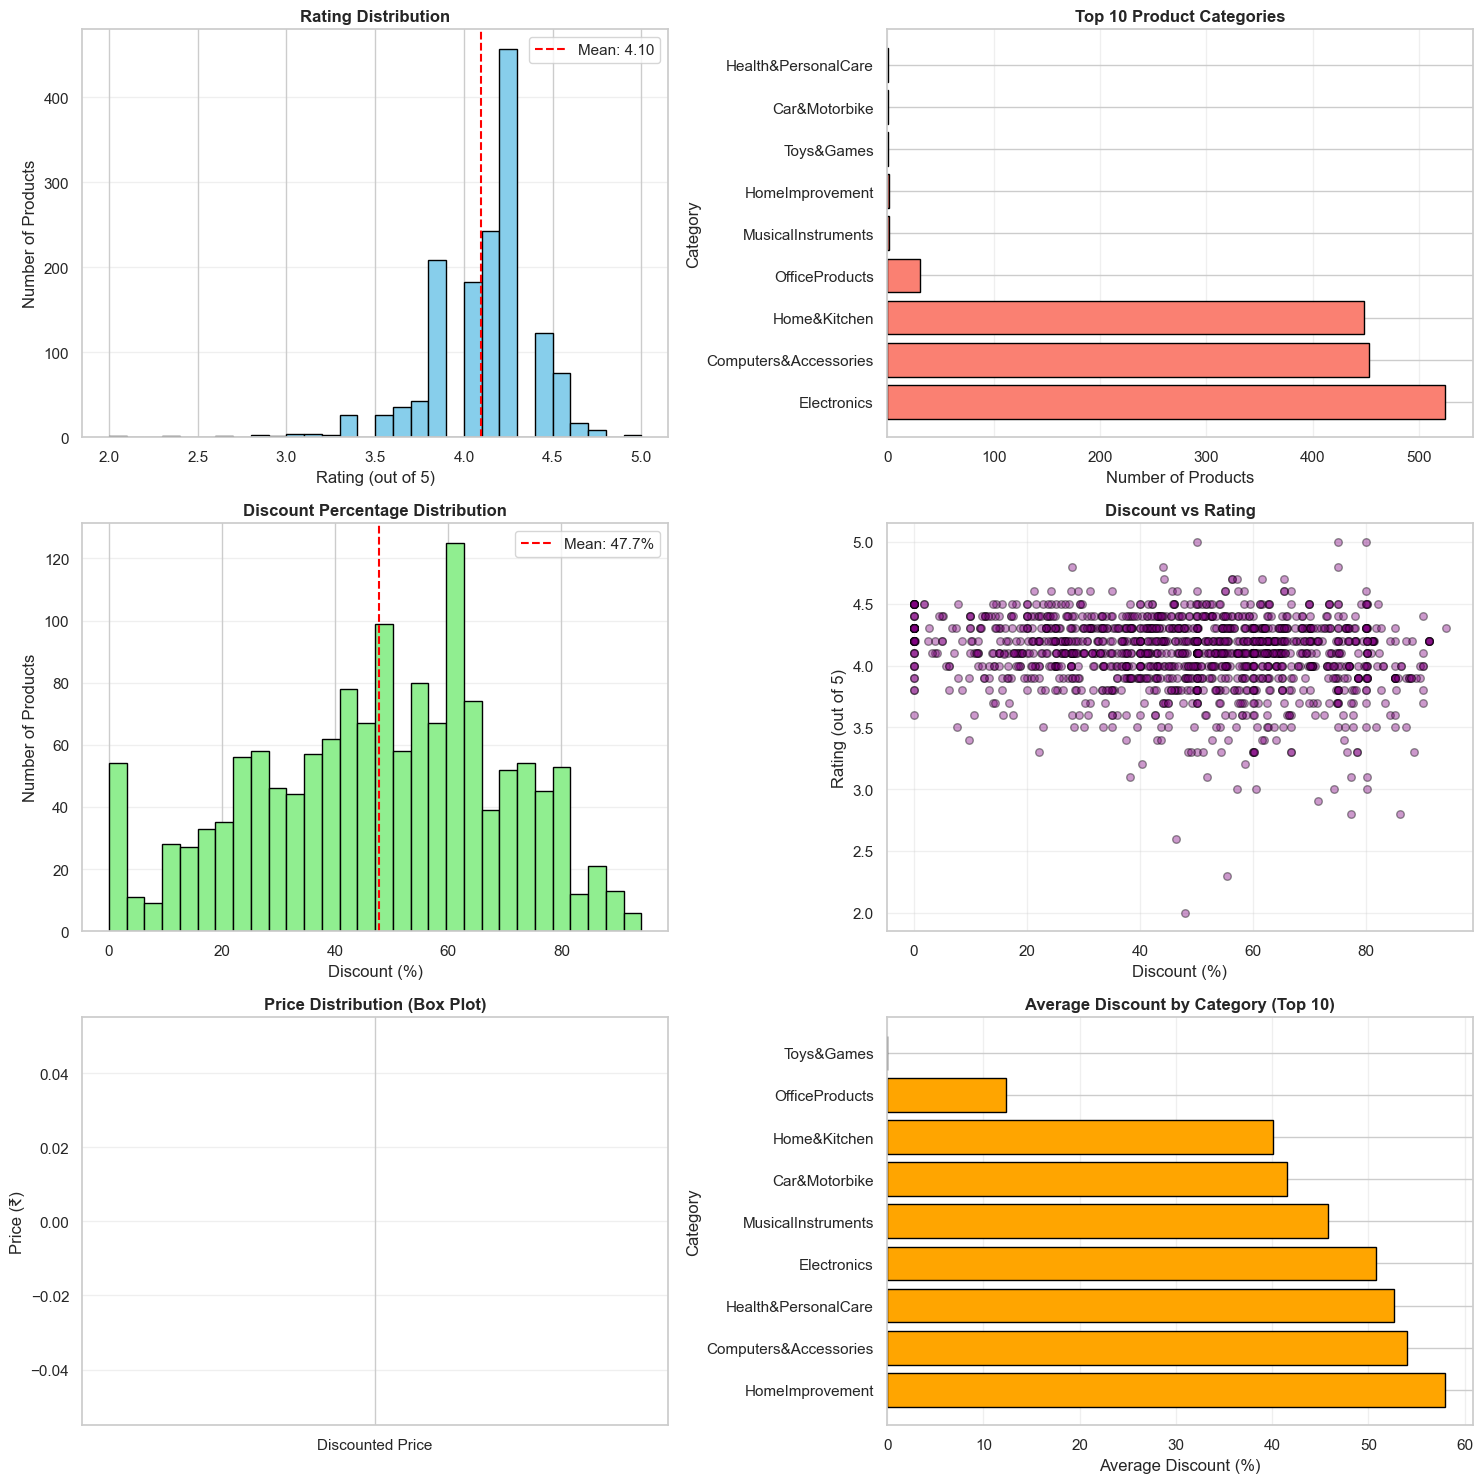



✓ Visualizations created successfully.


In [13]:
# ==========================================
# 5.1 CREATE VISUALIZATIONS
# ==========================================

# Set seaborn style
sns.set_theme(style="whitegrid")

# Create figure with 6 subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# 1. Rating Distribution (Histogram)
axes[0, 0].hist(df['rating_clean'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Rating Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Rating (out of 5)')
axes[0, 0].set_ylabel('Number of Products')
axes[0, 0].axvline(df['rating_clean'].mean(), color='red', linestyle='--', label=f"Mean: {df['rating_clean'].mean():.2f}")
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Top 10 Categories (Bar Chart)
top_10_categories = df['main_category'].value_counts().head(10)
axes[0, 1].barh(top_10_categories.index, top_10_categories.values, color='salmon', edgecolor='black')
axes[0, 1].set_title('Top 10 Product Categories', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Number of Products')
axes[0, 1].set_ylabel('Category')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Discount Distribution (Histogram)
axes[1, 0].hist(df['discount_percent_real'], bins=30, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Discount Percentage Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Discount (%)')
axes[1, 0].set_ylabel('Number of Products')
axes[1, 0].axvline(df['discount_percent_real'].mean(), color='red', linestyle='--', label=f"Mean: {df['discount_percent_real'].mean():.1f}%")
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Discount vs Rating (Scatter Plot)
axes[1, 1].scatter(df['discount_percent_real'], df['rating_clean'], alpha=0.4, color='purple', edgecolor='black', s=30)
axes[1, 1].set_title('Discount vs Rating', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Discount (%)')
axes[1, 1].set_ylabel('Rating (out of 5)')
axes[1, 1].grid(alpha=0.3)

# 5. Price Distribution (Box Plot)
axes[2, 0].boxplot([df['discounted_price_clean']], labels=['Discounted Price'])
axes[2, 0].set_title('Price Distribution (Box Plot)', fontsize=12, fontweight='bold')
axes[2, 0].set_ylabel('Price (₹)')
axes[2, 0].grid(axis='y', alpha=0.3)

# 6. Average Discount by Category (Top 10)
avg_discount_by_cat = df.groupby('main_category')['discount_percent_real'].mean().sort_values(ascending=False).head(10)
axes[2, 1].barh(avg_discount_by_cat.index, avg_discount_by_cat.values, color='orange', edgecolor='black')
axes[2, 1].set_title('Average Discount by Category (Top 10)', fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel('Average Discount (%)')
axes[2, 1].set_ylabel('Category')
axes[2, 1].grid(axis='x', alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.show()

print("\n" + "="*60 + "\n")
print("✓ Visualizations created successfully.")

## STEP 6: EXPORT & SUMMARY

In [14]:
# ==========================================
# 6.1 EXPORT CLEANED DATA TO CSV
# ==========================================

# Select relevant columns for export
export_columns = [
    'product_name',
    'main_category',
    'actual_price_clean',
    'discounted_price_clean',
    'discount_amount',
    'discount_percent_real',
    'rating_clean',
    'is_star_product'
]

# Create export dataframe
df_export = df[export_columns].copy()

# Rename columns for clarity
df_export.columns = [
    'Product Name',
    'Category',
    'Original Price (₹)',
    'Discounted Price (₹)',
    'Discount Amount (₹)',
    'Discount (%)',
    'Rating',
    'Star Product'
]

# Export to CSV
output_filename = 'amazon_sales_cleaned.csv'
df_export.to_csv(output_filename, index=False, encoding='utf-8')

print(f"✓ Data exported successfully to: {output_filename}")
print(f"Total records exported: {len(df_export)}")
print(f"Total columns: {len(df_export.columns)}")

print("\n" + "="*60 + "\n")

# Display preview of exported data
print("Preview of exported data:")
display(df_export.head(10))

print("\n" + "="*60 + "\n")
print("✓ Export completed successfully.")

✓ Data exported successfully to: amazon_sales_cleaned.csv
Total records exported: 1464
Total columns: 8


Preview of exported data:


,Product Name,Category,Original Price (₹),Discounted Price (₹),Discount Amount (₹),Discount (%),Rating,Star Product
0,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories,1099.0,399.00,700.00,63.694268,4.2,False
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories,349.0,199.00,150.00,42.979943,4.0,False
2,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories,1899.0,199.00,1700.00,89.520800,3.9,False
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories,699.0,329.00,370.00,52.932761,4.2,False
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories,399.0,154.00,245.00,61.403509,4.2,False
5,pTron Solero TB301 3A Type-C Data and Fast Cha...,Computers&Accessories,1000.0,149.00,851.00,85.100000,3.9,False
6,"boAt Micro USB 55 Tangle-free, Sturdy Micro US...",Computers&Accessories,499.0,176.63,322.37,64.603206,4.1,False
7,MI Usb Type-C Cable Smartphone (Black),Computers&Accessories,299.0,229.00,70.00,23.411371,4.3,False
8,"TP-Link USB WiFi Adapter for PC(TL-WN725N), N1...",Computers&Accessories,999.0,499.00,500.00,50.050050,4.2,False
9,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories,299.0,199.00,100.00,33.444816,4.0,False




✓ Export completed successfully.


In [15]:
# ==========================================
# 6.2 PROJECT SUMMARY AND INSIGHTS
# ==========================================

print("="*60)
print("AMAZON SALES EDA - EXECUTIVE SUMMARY")
print("="*60)
print()

# Dataset overview
print("DATASET OVERVIEW:")
print(f"  Source: Amazon India Sales Dataset (Kaggle)")
print(f"  Total products analyzed: {len(df):,}")
print(f"  Product categories: {df['main_category'].nunique()}")
print()

# Price insights
print("PRICE ANALYSIS:")
print(f"  Average discounted price: ₹{df['discounted_price_clean'].mean():,.2f}")
print(f"  Median discounted price: ₹{df['discounted_price_clean'].median():,.2f}")
print(f"  Price range: ₹{df['discounted_price_clean'].min():,.2f} - ₹{df['discounted_price_clean'].max():,.2f}")
print()

# Discount insights
print("DISCOUNT ANALYSIS:")
print(f"  Average discount: {df['discount_percent_real'].mean():.1f}%")
print(f"  Maximum discount: {df['discount_percent_real'].max():.1f}%")
print(f"  Products with >50% discount: {(df['discount_percent_real'] > 50).sum()} ({(df['discount_percent_real'] > 50).sum() / len(df) * 100:.1f}%)")
print()

# Rating insights
print("RATING ANALYSIS:")
print(f"  Average rating: {df['rating_clean'].mean():.2f} / 5.0")
print(f"  Products with rating ≥ 4.5: {(df['rating_clean'] >= 4.5).sum()} ({(df['rating_clean'] >= 4.5).sum() / len(df) * 100:.1f}%)")
print()

# Star products
star_count = df['is_star_product'].sum()
print("STAR PRODUCTS (Rating ≥ 4.5 AND Discount ≥ 50%):")
print(f"  Total star products: {star_count} ({star_count / len(df) * 100:.1f}% of catalog)")
print()

# Category insights
print("TOP 3 CATEGORIES:")
top_3_categories = df['main_category'].value_counts().head(3)
for i, (category, count) in enumerate(top_3_categories.items(), 1):
    print(f"  {i}. {category}: {count} products ({count / len(df) * 100:.1f}%)")
print()

# Correlation
correlation = df[['discount_percent_real', 'rating_clean']].corr().iloc[0, 1]
print("DISCOUNT vs RATING:")
print(f"  Correlation coefficient: {correlation:.3f}")
if abs(correlation) < 0.3:
    print("  → Weak correlation: Higher discounts do NOT guarantee better ratings")
print()

print("="*60)
print("KEY FINDINGS:")
print("="*60)
print()
print("1. AGGRESSIVE DISCOUNTING STRATEGY")
print(f"   → Average discount of {df['discount_percent_real'].mean():.1f}% indicates highly competitive pricing")
print(f"   → Over half of products ({(df['discount_percent_real'] > 50).sum() / len(df) * 100:.1f}%) have discounts exceeding 50%")
print()
print("2. STRONG CUSTOMER SATISFACTION")
print(f"   → Average rating of {df['rating_clean'].mean():.2f}/5.0 reflects good product quality")
print(f"   → {(df['rating_clean'] >= 4.5).sum() / len(df) * 100:.1f}% of products have excellent ratings (≥4.5)")
print()
print("3. DISCOUNT-RATING INDEPENDENCE")
print(f"   → Correlation of {correlation:.3f} shows discount % has minimal impact on ratings")
print("   → Price cuts alone don't improve customer satisfaction")
print()
print("4. CATEGORY CONCENTRATION")
top_cat = df['main_category'].value_counts().index[0]
top_cat_pct = (df['main_category'].value_counts().iloc[0] / len(df)) * 100
print(f"   → '{top_cat}' dominates with {top_cat_pct:.1f}% of total products")
print("   → Technology categories show highest product density")
print()

print("="*60)
print("✓ PROJECT COMPLETED SUCCESSFULLY")
print("="*60)
print()
print(f"Results exported to: {output_filename}")
print("Use this file for further analysis, dashboards, or business insights.")

AMAZON SALES EDA - EXECUTIVE SUMMARY

DATASET OVERVIEW:
  Source: Amazon India Sales Dataset (Kaggle)
  Total products analyzed: 1,464
  Product categories: 9

PRICE ANALYSIS:
  Average discounted price: ₹3,127.79
  Median discounted price: ₹799.00
  Price range: ₹39.00 - ₹77,990.00

DISCOUNT ANALYSIS:
  Average discount: 47.7%
  Maximum discount: 94.1%
  Products with >50% discount: 738 (50.4%)

RATING ANALYSIS:
  Average rating: 4.10 / 5.0
  Products with rating ≥ 4.5: 104 (7.1%)

STAR PRODUCTS (Rating ≥ 4.5 AND Discount ≥ 50%):
  Total star products: 50 (3.4% of catalog)

TOP 3 CATEGORIES:
  1. Electronics: 524 products (35.8%)
  2. Computers&Accessories: 453 products (30.9%)
  3. Home&Kitchen: 448 products (30.6%)

DISCOUNT vs RATING:
  Correlation coefficient: -0.156
  → Weak correlation: Higher discounts do NOT guarantee better ratings

KEY FINDINGS:

1. AGGRESSIVE DISCOUNTING STRATEGY
   → Average discount of 47.7% indicates highly competitive pricing
   → Over half of products 